# AquaGuard – Water Quality Prediction
### ARTI 406 – Machine Learning | Group 2 – Section 8FA3

**Members:**
- Sara Falah Alsahli
- Lamya Khalid Alansari
- Tala Abdullah Alghamdi
- Sara Mousa Almousa
- Samar Ali Alyami

---

This notebook implements the full AquaGuard machine learning pipeline for predicting water potability.

**Models used:** K-Nearest Neighbors (KNN), Random Forest, XGBoost

**Dataset:** Kaggle Water Potability Dataset (3,276 samples, 9 features)

---
## Step 1: Import Libraries

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Display plots inline in the notebook
%matplotlib inline

# Set a clean visual style for all plots
sns.set(style='whitegrid')

# Set a random seed for reproducibility
RANDOM_STATE = 42

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load the Dataset

In [2]:
# Load the Water Potability dataset from CSV file
df = pd.read_csv('water_potability.csv')

# Display the first 5 rows to understand the data structure
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Check the shape of the dataset (rows, columns)
print('Dataset Shape:', df.shape)

# Display column names and data types
print('\nDataset Info:')
print(df.info())

Dataset Shape: (3276, 10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None


---
## Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Display basic statistical summary of all features
# This shows mean, median, std, min, max for each column
df.describe().round(2)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97,0.39
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78,0.49
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45,0.00
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44,0.00
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96,0.00
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50,1.00
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74,1.00


In [5]:
# Check for missing values in each column
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing Values per Column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Total missing values: 1434


In [6]:
# Check the class distribution (how many potable vs non-potable samples)
print('Class Distribution:')
print(df['Potability'].value_counts())
print('\nPercentage:')
print(df['Potability'].value_counts(normalize=True).round(2) * 100)

Class Distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64

Percentage:
Potability
0    61.0
1    39.0
Name: proportion, dtype: float64


/var/folders/2j/gvpfw7kn42j5gln81jlqvr6r0000gn/T/ipykernel_18886/1231980932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette='Set2')


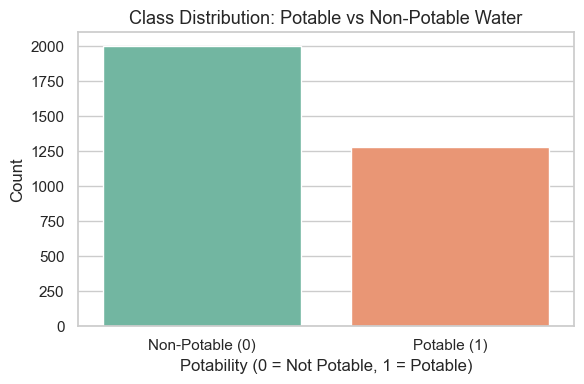

In [7]:
# Plot the class distribution as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, palette='Set2')

# Add labels to the bars
plt.title('Class Distribution: Potable vs Non-Potable Water', fontsize=13)
plt.xlabel('Potability (0 = Not Potable, 1 = Potable)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Potable (0)', 'Potable (1)'])
plt.tight_layout()
plt.show()

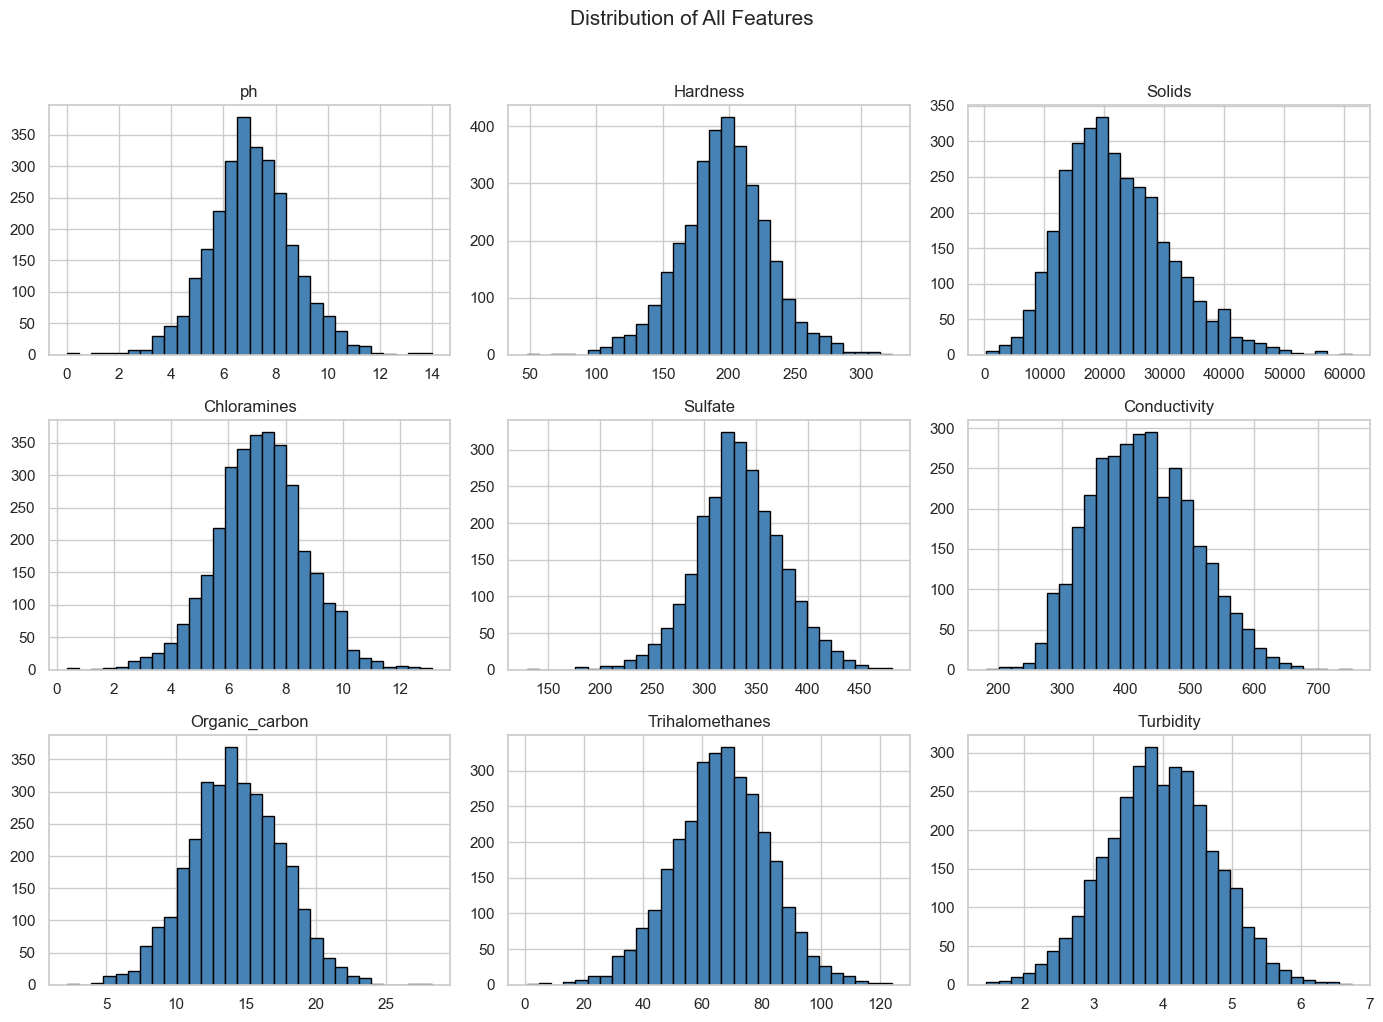

In [8]:
# Plot the distribution of each feature using histograms
# This helps us understand the spread and shape of each variable
df.drop('Potability', axis=1).hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

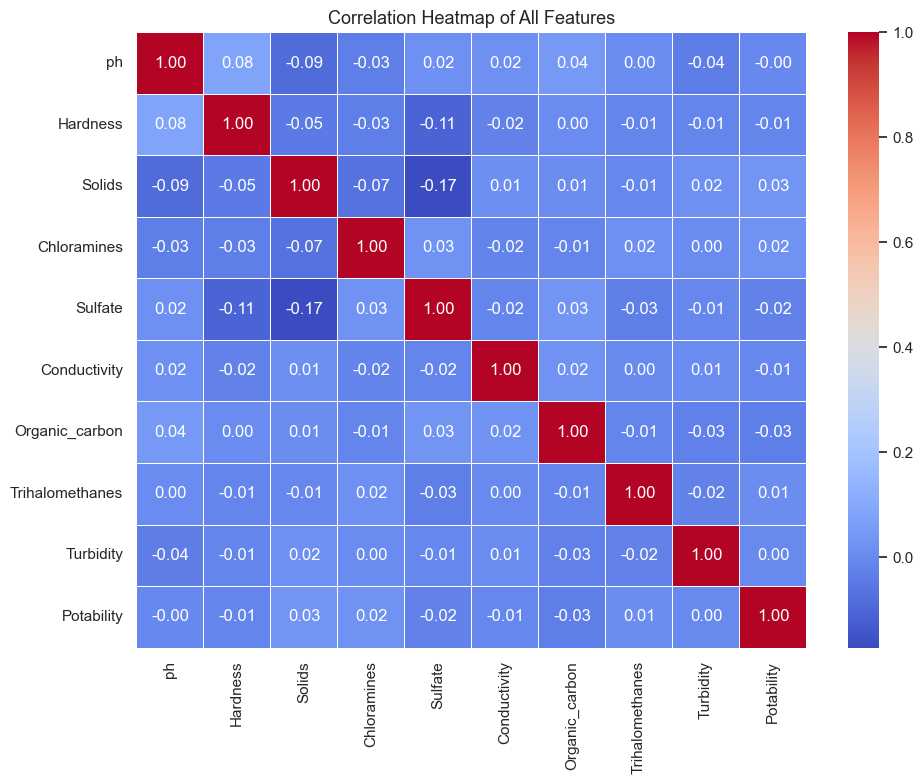

In [9]:
# Plot a correlation heatmap to see relationships between features
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Show correlation of each feature with the target variable (Potability)
print('Correlation of Each Feature with Potability:')
print(df.corr()['Potability'].sort_values(ascending=False).round(4))

Correlation of Each Feature with Potability:
Potability         1.0000
Solids             0.0337
Chloramines        0.0238
Trihalomethanes    0.0071
Turbidity          0.0016
ph                -0.0036
Conductivity      -0.0081
Hardness          -0.0138
Sulfate           -0.0236
Organic_carbon    -0.0300
Name: Potability, dtype: float64


---
## Step 4: Data Preprocessing

In [11]:
# Handle missing values using median imputation
# We use median instead of mean because it is more robust to outliers
df.fillna(df.median(), inplace=True)

# Verify that all missing values have been handled
print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [12]:
# Separate features (X) and target variable (y)
# X contains all 9 physicochemical features
X = df.drop('Potability', axis=1)

# y contains the target label (0 = Not Potable, 1 = Potable)
y = df['Potability']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (3276, 9)
Target shape: (3276,)


In [13]:
# Apply Min-Max Normalization to scale all features to range [0, 1]
# This is essential for KNN which is sensitive to feature scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame to keep column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Features after Min-Max Normalization:')
X_scaled.describe().round(2)

Features after Min-Max Normalization:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00
mean,0.51,0.54,0.36,0.53,0.58,0.43,0.46,0.53,0.48
std,0.11,0.12,0.14,0.12,0.10,0.14,0.13,0.13,0.15
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.45,0.47,0.25,0.45,0.53,0.32,0.38,0.45,0.38
50%,0.50,0.54,0.34,0.53,0.58,0.42,0.46,0.53,0.47
75%,0.56,0.61,0.44,0.61,0.63,0.53,0.55,0.62,0.58
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [14]:
# Split dataset into 80% training and 20% testing sets
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (2620, 9)
Testing set size: (656, 9)


---
## Step 5: K-Nearest Neighbors (KNN)
### 5.1 Finding the Optimal K Value

In [15]:
# Find the optimal value of K by testing K from 1 to 40
# We record the error rate for each K value
error_rate = []

for k in range(1, 41):
    # Train KNN model with current K value
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Predict on test set
    pred = knn.predict(X_test)
    
    # Calculate error rate (1 - accuracy)
    error_rate.append(np.mean(pred != y_test))

print('Error rates calculated for K = 1 to 40')

Error rates calculated for K = 1 to 40


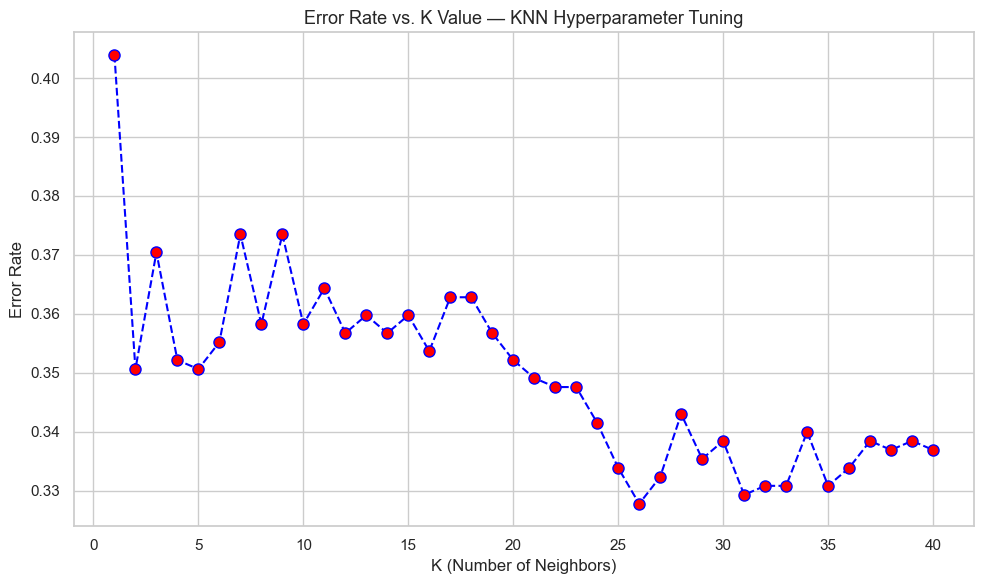

Best K value: 26 with error rate: 0.3277


In [16]:
# Plot the error rate vs K value to find the optimal K
plt.figure(figsize=(10, 6))
plt.plot(range(1, 41), error_rate, color='blue', linestyle='dashed',
         marker='o', markerfacecolor='red', markersize=8)

# Add title and labels
plt.title('Error Rate vs. K Value — KNN Hyperparameter Tuning', fontsize=13)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.tight_layout()
plt.show()

# Find the K with the lowest error rate
best_k = error_rate.index(min(error_rate)) + 1
print(f'Best K value: {best_k} with error rate: {min(error_rate):.4f}')

### 5.2 Train KNN with Optimal K

In [17]:
# Train the final KNN model using the best K value found above
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Make predictions on the test set
knn_pred = knn_final.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f'KNN Accuracy with K={best_k}: {knn_accuracy:.4f}')

KNN Accuracy with K=26: 0.6723


In [18]:
# Display detailed classification report for KNN
# Shows precision, recall, F1-score for each class
print('KNN Classification Report:')
print('='*50)
print(classification_report(y_test, knn_pred, target_names=['Non-Potable', 'Potable']))

KNN Classification Report:
              precision    recall  f1-score   support

 Non-Potable       0.67      0.95      0.78       412
     Potable       0.70      0.20      0.32       244

    accuracy                           0.67       656
   macro avg       0.69      0.58      0.55       656
weighted avg       0.68      0.67      0.61       656



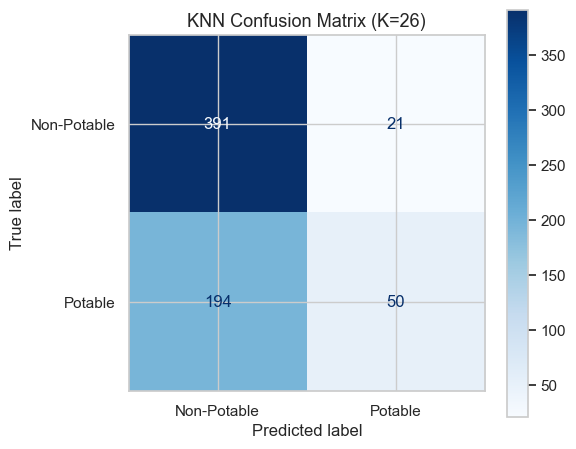

In [19]:
# Plot the confusion matrix for KNN
# Shows true positives, true negatives, false positives, false negatives
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Non-Potable', 'Potable'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'KNN Confusion Matrix (K={best_k})', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 6: Random Forest
### 6.1 Hyperparameter Tuning for Random Forest

In [20]:
# Test different numbers of trees (n_estimators) to find the best value
# More trees generally means better performance but slower training
n_estimators_range = [10, 50, 100, 150, 200, 250, 300]
rf_scores = []

for n in n_estimators_range:
    # Train Random Forest with current number of trees
    rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    
    # Record accuracy on test set
    score = accuracy_score(y_test, rf.predict(X_test))
    rf_scores.append(score)

print('Random Forest accuracy for different n_estimators:')
for n, s in zip(n_estimators_range, rf_scores):
    print(f'  n_estimators={n}: Accuracy={s:.4f}')

Random Forest accuracy for different n_estimators:
  n_estimators=10: Accuracy=0.6357
  n_estimators=50: Accuracy=0.6829
  n_estimators=100: Accuracy=0.6723
  n_estimators=150: Accuracy=0.6768
  n_estimators=200: Accuracy=0.6829
  n_estimators=250: Accuracy=0.6829
  n_estimators=300: Accuracy=0.6875


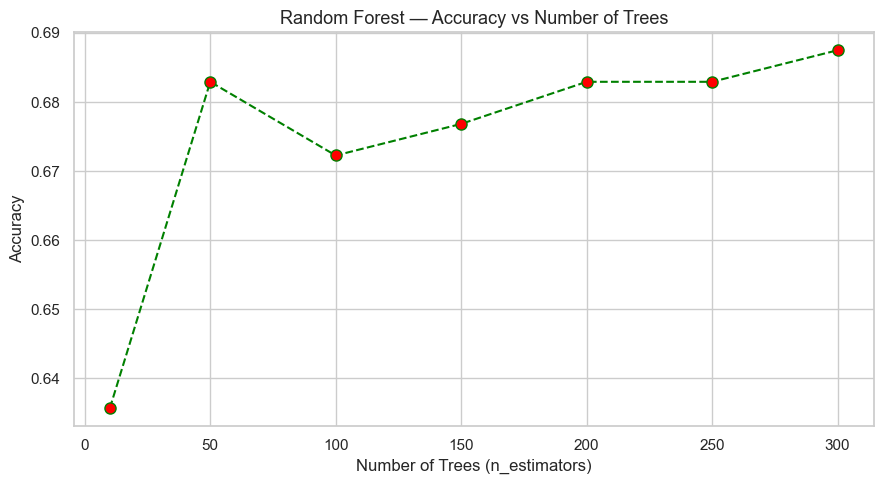

Best n_estimators: 300 with accuracy: 0.6875


In [21]:
# Plot accuracy vs number of trees
plt.figure(figsize=(9, 5))
plt.plot(n_estimators_range, rf_scores, color='green', linestyle='dashed',
         marker='o', markerfacecolor='red', markersize=8)
plt.title('Random Forest — Accuracy vs Number of Trees', fontsize=13)
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# Find the best number of trees
best_n = n_estimators_range[rf_scores.index(max(rf_scores))]
print(f'Best n_estimators: {best_n} with accuracy: {max(rf_scores):.4f}')

In [22]:
# Test different max_depth values to control tree depth
# Deeper trees can overfit; shallower trees may underfit
max_depth_range = [None, 5, 10, 15, 20, 25, 30]
rf_depth_scores = []

for d in max_depth_range:
    rf = RandomForestClassifier(n_estimators=best_n, max_depth=d, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    score = accuracy_score(y_test, rf.predict(X_test))
    rf_depth_scores.append(score)

# Display results
depth_labels = ['None', '5', '10', '15', '20', '25', '30']
print('Random Forest accuracy for different max_depth values:')
for d, s in zip(depth_labels, rf_depth_scores):
    print(f'  max_depth={d}: Accuracy={s:.4f}')

# Find best max_depth
best_depth = max_depth_range[rf_depth_scores.index(max(rf_depth_scores))]
print(f'\nBest max_depth: {best_depth}')

Random Forest accuracy for different max_depth values:
  max_depth=None: Accuracy=0.6875
  max_depth=5: Accuracy=0.6601
  max_depth=10: Accuracy=0.6799
  max_depth=15: Accuracy=0.6799
  max_depth=20: Accuracy=0.6921
  max_depth=25: Accuracy=0.6814
  max_depth=30: Accuracy=0.6890

Best max_depth: 20


### 6.2 Train Final Random Forest Model

In [23]:
# Train the final Random Forest model with optimal parameters
rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=RANDOM_STATE
)
rf_final.fit(X_train, y_train)

# Make predictions on the test set
rf_pred = rf_final.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Accuracy: 0.6921


In [24]:
# Display detailed classification report for Random Forest
print('Random Forest Classification Report:')
print('='*50)
print(classification_report(y_test, rf_pred, target_names=['Non-Potable', 'Potable']))

Random Forest Classification Report:
              precision    recall  f1-score   support

 Non-Potable       0.70      0.90      0.79       412
     Potable       0.67      0.34      0.45       244

    accuracy                           0.69       656
   macro avg       0.68      0.62      0.62       656
weighted avg       0.69      0.69      0.66       656



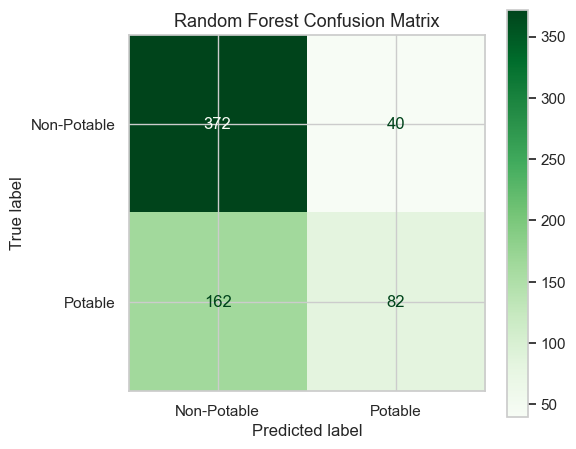

In [25]:
# Plot confusion matrix for Random Forest
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Non-Potable', 'Potable'])
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Random Forest Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/2j/gvpfw7kn42j5gln81jlqvr6r0000gn/T/ipykernel_18886/3200898867.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


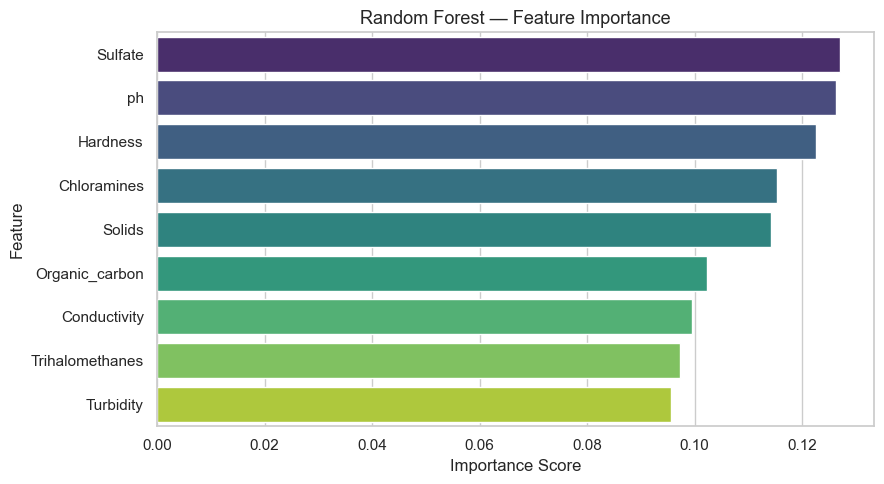

Feature Importance Rankings:
Sulfate            0.1270
ph                 0.1263
Hardness           0.1226
Chloramines        0.1152
Solids             0.1143
Organic_carbon     0.1023
Conductivity       0.0994
Trihalomethanes    0.0973
Turbidity          0.0955
dtype: float64


In [26]:
# Plot feature importance from Random Forest
# This shows which chemical parameters are most important for predicting potability
feature_importance = pd.Series(
    rf_final.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Random Forest — Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Feature Importance Rankings:')
print(feature_importance.round(4))

---
## Step 7: XGBoost
### 7.1 Hyperparameter Tuning for XGBoost

In [27]:
# Test different learning rates for XGBoost
# Learning rate controls how much each tree contributes to the final model
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
xgb_lr_scores = []

for lr in learning_rates:
    # Train XGBoost with current learning rate
    xgb = XGBClassifier(
        learning_rate=lr,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb.fit(X_train, y_train)
    score = accuracy_score(y_test, xgb.predict(X_test))
    xgb_lr_scores.append(score)

print('XGBoost accuracy for different learning rates:')
for lr, s in zip(learning_rates, xgb_lr_scores):
    print(f'  learning_rate={lr}: Accuracy={s:.4f}')

# Find best learning rate
best_lr = learning_rates[xgb_lr_scores.index(max(xgb_lr_scores))]
print(f'\nBest learning_rate: {best_lr}')

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

XGBoost accuracy for different learning rates:
  learning_rate=0.01: Accuracy=0.6570
  learning_rate=0.05: Accuracy=0.6845
  learning_rate=0.1: Accuracy=0.6707
  learning_rate=0.2: Accuracy=0.6601
  learning_rate=0.3: Accuracy=0.6570
  learning_rate=0.5: Accuracy=0.6418

Best learning_rate: 0.05


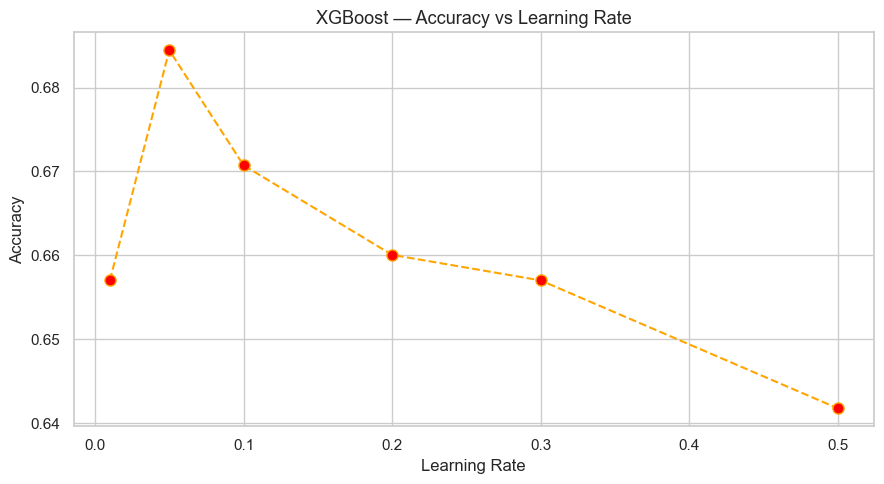

In [28]:
# Plot accuracy vs learning rate for XGBoost
plt.figure(figsize=(9, 5))
plt.plot(learning_rates, xgb_lr_scores, color='orange', linestyle='dashed',
         marker='o', markerfacecolor='red', markersize=8)
plt.title('XGBoost — Accuracy vs Learning Rate', fontsize=13)
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [29]:
# Test different max_depth values for XGBoost
# Controls how deep each decision tree can grow
xgb_depth_range = [3, 4, 5, 6, 7, 8, 9, 10]
xgb_depth_scores = []

for d in xgb_depth_range:
    xgb = XGBClassifier(
        learning_rate=best_lr,
        max_depth=d,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb.fit(X_train, y_train)
    score = accuracy_score(y_test, xgb.predict(X_test))
    xgb_depth_scores.append(score)

print('XGBoost accuracy for different max_depth values:')
for d, s in zip(xgb_depth_range, xgb_depth_scores):
    print(f'  max_depth={d}: Accuracy={s:.4f}')

# Find best max_depth
best_xgb_depth = xgb_depth_range[xgb_depth_scores.index(max(xgb_depth_scores))]
print(f'\nBest max_depth: {best_xgb_depth}')

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

XGBoost accuracy for different max_depth values:
  max_depth=3: Accuracy=0.6646
  max_depth=4: Accuracy=0.6585
  max_depth=5: Accuracy=0.6585
  max_depth=6: Accuracy=0.6845
  max_depth=7: Accuracy=0.6905
  max_depth=8: Accuracy=0.6799
  max_depth=9: Accuracy=0.6677
  max_depth=10: Accuracy=0.6631

Best max_depth: 7


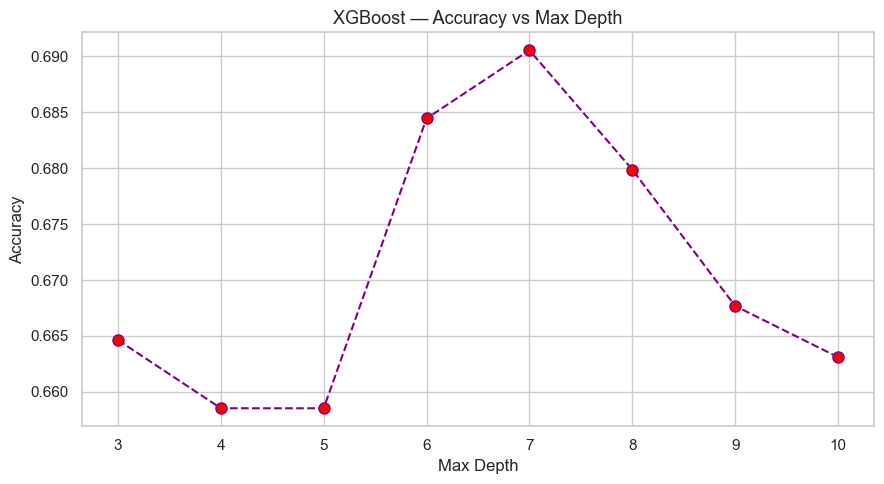

In [30]:
# Plot accuracy vs max_depth for XGBoost
plt.figure(figsize=(9, 5))
plt.plot(xgb_depth_range, xgb_depth_scores, color='purple', linestyle='dashed',
         marker='o', markerfacecolor='red', markersize=8)
plt.title('XGBoost — Accuracy vs Max Depth', fontsize=13)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

### 7.2 Train Final XGBoost Model

In [31]:
# Train the final XGBoost model with optimal parameters
xgb_final = XGBClassifier(
    learning_rate=best_lr,
    max_depth=best_xgb_depth,
    n_estimators=200,         # Number of boosting rounds
    subsample=0.8,            # Fraction of samples used per tree
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_final.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred = xgb_final.predict(X_test)

# Calculate accuracy
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}')

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [23:29:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6860


In [32]:
# Display detailed classification report for XGBoost
print('XGBoost Classification Report:')
print('='*50)
print(classification_report(y_test, xgb_pred, target_names=['Non-Potable', 'Potable']))

XGBoost Classification Report:
              precision    recall  f1-score   support

 Non-Potable       0.71      0.85      0.77       412
     Potable       0.62      0.41      0.49       244

    accuracy                           0.69       656
   macro avg       0.66      0.63      0.63       656
weighted avg       0.67      0.69      0.67       656



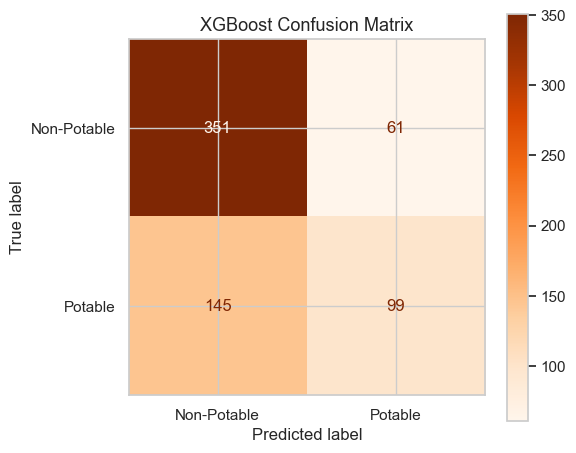

In [33]:
# Plot confusion matrix for XGBoost
plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Non-Potable', 'Potable'])
disp.plot(cmap='Oranges', ax=plt.gca())
plt.title('XGBoost Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 8: Feature Selection
### Testing Different Feature Subsets

In [34]:
# Use SelectKBest to rank features by their statistical score
# f_classif computes the ANOVA F-value between each feature and the target
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)

# Create a DataFrame to show feature scores
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print('Feature Scores (Higher = More Important):')
print(feature_scores.to_string(index=False))

Feature Scores (Higher = More Important):
        Feature    Score
         Solids 3.732062
 Organic_carbon 2.949523
    Chloramines 1.852296
        Sulfate 1.373307
       Hardness 0.626928
   Conductivity 0.216326
Trihalomethanes 0.155277
             ph 0.029741
      Turbidity 0.008180


/var/folders/2j/gvpfw7kn42j5gln81jlqvr6r0000gn/T/ipykernel_18886/1177710347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores, palette='coolwarm')


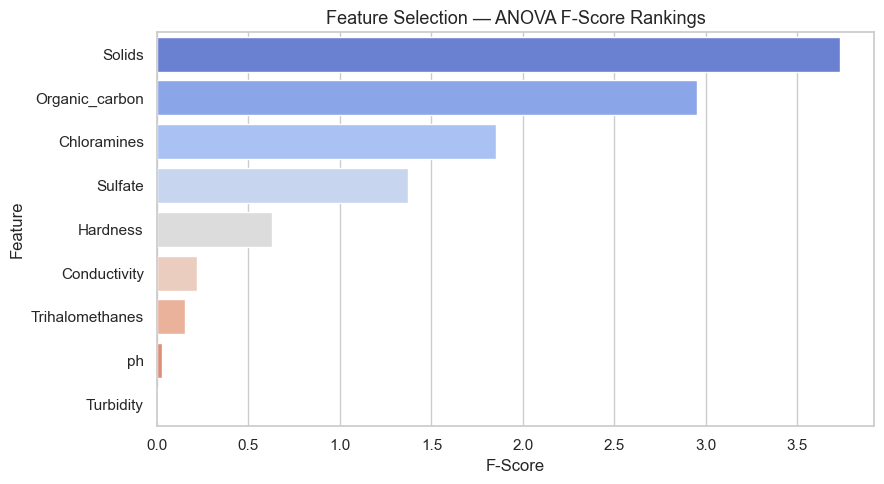

In [35]:
# Plot feature scores as a bar chart
plt.figure(figsize=(9, 5))
sns.barplot(x='Score', y='Feature', data=feature_scores, palette='coolwarm')
plt.title('Feature Selection — ANOVA F-Score Rankings', fontsize=13)
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [36]:
# Compare model performance using different numbers of features
# We test: All 9 features, best 7 features, best 5 features, best 3 features
feature_subsets = [9, 7, 5, 3]

# Store results for each subset
results = []

for k in feature_subsets:
    # Select the top k features
    selector_k = SelectKBest(score_func=f_classif, k=k)
    X_selected = selector_k.fit_transform(X_scaled, y)
    
    # Get names of selected features
    selected_features = X.columns[selector_k.get_support()].tolist()
    
    # Split into train and test sets
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=0.2, random_state=RANDOM_STATE
    )
    
    # Train and evaluate KNN
    knn_k = KNeighborsClassifier(n_neighbors=best_k)
    knn_k.fit(X_tr, y_tr)
    knn_score = accuracy_score(y_te, knn_k.predict(X_te))
    
    # Train and evaluate Random Forest
    rf_k = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, random_state=RANDOM_STATE)
    rf_k.fit(X_tr, y_tr)
    rf_score = accuracy_score(y_te, rf_k.predict(X_te))
    
    # Store results
    results.append({
        'Features Used': k,
        'Selected Features': ', '.join(selected_features),
        'KNN Accuracy': round(knn_score, 4),
        'RF Accuracy': round(rf_score, 4)
    })

# Display results as a table
results_df = pd.DataFrame(results)
print('Feature Selection Results:')
print(results_df.to_string(index=False))

Feature Selection Results:
 Features Used                                                                                    Selected Features  KNN Accuracy  RF Accuracy
             9 ph, Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic_carbon, Trihalomethanes, Turbidity        0.6723       0.6921
             7                Hardness, Solids, Chloramines, Sulfate, Conductivity, Organic_carbon, Trihalomethanes        0.6540       0.6494
             5                                               Hardness, Solids, Chloramines, Sulfate, Organic_carbon        0.6555       0.6433
             3                                                                  Solids, Chloramines, Organic_carbon        0.6189       0.5991


---
## Step 9: Final Comparison of All Models

In [37]:
# Collect final results for all three models
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate all metrics for each model
models = ['KNN', 'Random Forest', 'XGBoost']
predictions = [knn_pred, rf_pred, xgb_pred]

final_results = []
for model, pred in zip(models, predictions):
    final_results.append({
        'Model': model,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall': round(recall_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4)
    })

# Display as a clean comparison table
final_df = pd.DataFrame(final_results)
print('Final Performance Comparison of All Models:')
print('='*60)
print(final_df.to_string(index=False))

Final Performance Comparison of All Models:
        Model  Accuracy  Precision  Recall  F1-Score
          KNN    0.6723     0.7042  0.2049    0.3175
Random Forest    0.6921     0.6721  0.3361    0.4481
      XGBoost    0.6860     0.6188  0.4057    0.4901


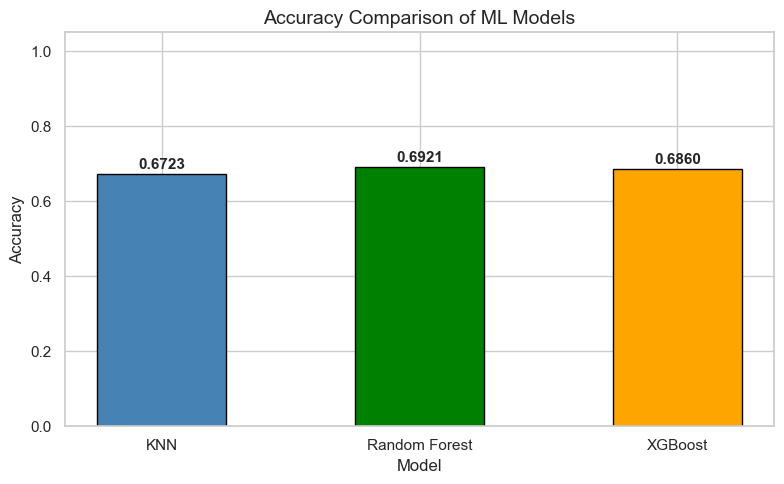

In [38]:
# Plot accuracy comparison bar chart for all three models
plt.figure(figsize=(8, 5))
colors = ['steelblue', 'green', 'orange']
bars = plt.bar(final_df['Model'], final_df['Accuracy'], color=colors, edgecolor='black', width=0.5)

# Add value labels on top of each bar
for bar, acc in zip(bars, final_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Accuracy Comparison of ML Models', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

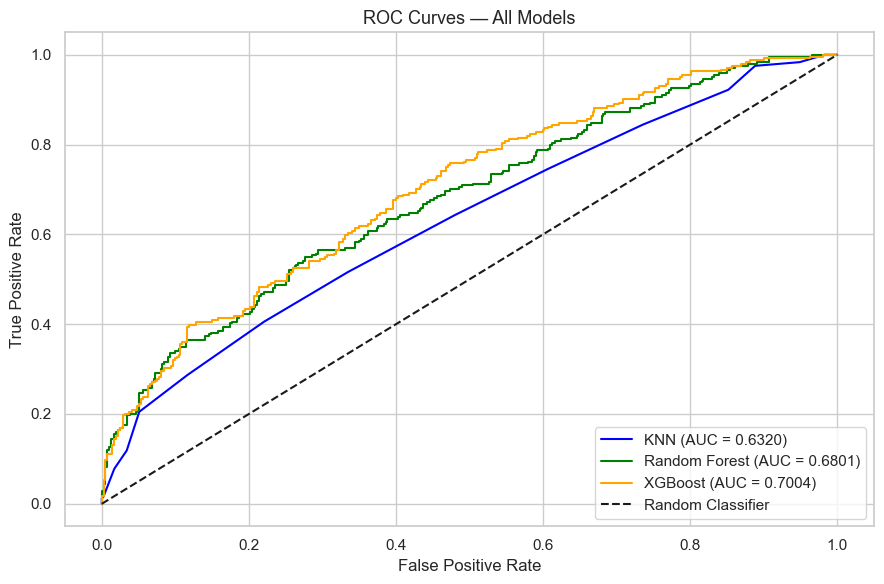

In [39]:
# Plot ROC curves for all three models
# ROC curve shows the trade-off between true positive rate and false positive rate
plt.figure(figsize=(9, 6))

# Get predicted probabilities for each model
knn_proba = knn_final.predict_proba(X_test)[:, 1]
rf_proba = rf_final.predict_proba(X_test)[:, 1]
xgb_proba = xgb_final.predict_proba(X_test)[:, 1]

# Calculate ROC curve for each model
for proba, name, color in zip(
    [knn_proba, rf_proba, xgb_proba],
    ['KNN', 'Random Forest', 'XGBoost'],
    ['blue', 'green', 'orange']
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc:.4f})')

# Plot the diagonal baseline (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.title('ROC Curves — All Models', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Step 10: Summary of Optimal Parameters

In [40]:
# Display a clean summary of the optimal parameters found for each model
print('='*50)
print('OPTIMAL PARAMETERS SUMMARY')
print('='*50)
print(f'KNN:')
print(f'  Best K (n_neighbors) = {best_k}')
print()
print(f'Random Forest:')
print(f'  Best n_estimators    = {best_n}')
print(f'  Best max_depth       = {best_depth}')
print()
print(f'XGBoost:')
print(f'  Best learning_rate   = {best_lr}')
print(f'  Best max_depth       = {best_xgb_depth}')
print(f'  n_estimators         = 200')
print(f'  subsample            = 0.8')
print('='*50)

OPTIMAL PARAMETERS SUMMARY
KNN:
  Best K (n_neighbors) = 26

Random Forest:
  Best n_estimators    = 300
  Best max_depth       = 20

XGBoost:
  Best learning_rate   = 0.05
  Best max_depth       = 7
  n_estimators         = 200
  subsample            = 0.8


In [41]:
# Final summary message
best_model = final_df.loc[final_df['Accuracy'].idxmax(), 'Model']
best_accuracy = final_df['Accuracy'].max()

print('='*50)
print('AQUAGUARD — FINAL RESULTS SUMMARY')
print('='*50)
print(f'Best performing model : {best_model}')
print(f'Best accuracy achieved: {best_accuracy:.4f}')
print()
print('All models compared:')
print(final_df.to_string(index=False))
print('='*50)

AQUAGUARD — FINAL RESULTS SUMMARY
Best performing model : Random Forest
Best accuracy achieved: 0.6921

All models compared:
        Model  Accuracy  Precision  Recall  F1-Score
          KNN    0.6723     0.7042  0.2049    0.3175
Random Forest    0.6921     0.6721  0.3361    0.4481
      XGBoost    0.6860     0.6188  0.4057    0.4901
